# Fine-tune Qwen2.5-1.5B-Instruct cho bài toán tóm tắt tiếng Việt trên Google Colab — cấu hình A100 40GB

Notebook này được chỉnh cho môi trường Google Colab dùng A100 40GB. Pipeline gồm: đọc dữ liệu parquet, format dữ liệu theo ChatML, fine-tune Qwen bằng QLoRA, vẽ biểu đồ loss, sinh tóm tắt trên validation/test và tính đầy đủ các độ đo đánh giá.

## Cell 1 — Cài đặt thư viện

Cell này cài các thư viện cần thiết cho toàn bộ pipeline: Hugging Face Transformers, Datasets, TRL, PEFT, BitsAndBytes, thư viện metric và thư viện vẽ biểu đồ.  
Chạy cell này đầu tiên mỗi khi mở runtime Colab mới.


In [1]:
!pip install -q -U transformers datasets trl peft bitsandbytes accelerate
!pip install -q -U evaluate rouge_score sacrebleu bert-score sentencepiece matplotlib pandas pyarrow tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 55.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.0 MB/s eta 0:00:00
   

## Cell 2 — Import thư viện và khai báo cấu hình Colab/A100 40GB

Cell này gom toàn bộ cấu hình quan trọng vào một nơi: tên model, đường dẫn dữ liệu, thư mục output, tham số train, tham số sinh tóm tắt và bật/tắt các metric.  
Bản này đã được chỉnh về cấu hình cân bằng cho A100 40GB: dùng QLoRA 4-bit, BF16 nếu GPU hỗ trợ, batch hiệu dụng 16 và lưu riêng output vào thư mục `qwen2_5_1_5b_qlora_a100_40gb`.

In [2]:
import os
import gc
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    TrainerCallback,
)
from peft import (
    LoraConfig,
    PeftModel,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer, SFTConfig

# ============================================================
# 1. Cấu hình chung
# ============================================================
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
SEED = 42

# Bật DEBUG_MODE=True nếu chỉ muốn chạy thử nhanh với ít mẫu.
DEBUG_MODE = False
DEBUG_TRAIN_SIZE = 100
DEBUG_VAL_SIZE = 20
DEBUG_TEST_SIZE = 20

# ============================================================
# 2. Đường dẫn Colab
# ============================================================
PROJECT_DIR = Path("/content/NLP")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_ROOT = PROJECT_DIR / "output"

TRAIN_PATH = DATA_DIR / "train.parquet"

# Hỗ trợ nhiều tên file validation thường gặp.
VAL_CANDIDATES = [
    DATA_DIR / "val.parquet",
    DATA_DIR / "valid.parquet",
    DATA_DIR / "validation.parquet",
]

# Test set có thể vài hôm nữa mới được cung cấp.
TEST_CANDIDATES = [
    DATA_DIR / "test.parquet",
    DATA_DIR / "private_test.parquet",
]

# Output của bản A100 40GB được lưu riêng để không ghi đè bản cũ.
RUN_NAME = "qwen2_5_1_5b_qlora_a100_40gb"
OUTPUT_DIR = OUTPUT_ROOT / RUN_NAME
ADAPTER_DIR = OUTPUT_DIR / "qwen-summary-adapter"
FORMATTED_DATA_DIR = OUTPUT_DIR / "formatted_dataset"

VAL_PRED_CSV = OUTPUT_DIR / "qwen_a100_40gb_validation_predictions.csv"
VAL_METRICS_JSON = OUTPUT_DIR / "qwen_a100_40gb_validation_metrics.json"

TEST_PRED_CSV = OUTPUT_DIR / "qwen_a100_40gb_test_predictions.csv"
TEST_METRICS_JSON = OUTPUT_DIR / "qwen_a100_40gb_test_metrics.json"

LOSS_HISTORY_CSV = OUTPUT_DIR / "qwen_a100_40gb_loss_history.csv"
LOSS_CURVE_PNG = OUTPUT_DIR / "qwen_a100_40gb_loss_curve.png"
EPOCH_LOSS_HISTORY_CSV = OUTPUT_DIR / "qwen_a100_40gb_epoch_loss_history.csv"
EPOCH_LOSS_CURVE_PNG = OUTPUT_DIR / "qwen_a100_40gb_epoch_loss_curve.png"
OUTPUT_ZIP = OUTPUT_ROOT / f"{RUN_NAME}_outputs.zip"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FORMATTED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 3. Cấu hình train cho A100 40GB
# ============================================================
# MAX_SEQ_LENGTH là tổng độ dài prompt + article + summary trong causal LM.
# A100 40GB có thể chạy 1024 khá an toàn với Qwen2.5-1.5B QLoRA.
MAX_SEQ_LENGTH = 1024

# Không nên train quá nhiều epoch ngay vì dataset không quá lớn.
# Hãy so sánh ROUGE/BERTScore sau train để quyết định có cần tăng epoch không.
NUM_TRAIN_EPOCHS = 3

# Cấu hình cân bằng cho A100 40GB.
# Effective batch size = 4 * 4 = 16.
PER_DEVICE_TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4

# QLoRA thường dùng LR khoảng 1e-4 đến 2e-4. Bản này chọn 2e-4 để học đủ nhanh.
LEARNING_RATE = 2e-4
LR_SCHEDULER_TYPE = "cosine"
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

LOGGING_STEPS = 10
EVAL_STEPS = 100
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 2
EARLY_STOPPING_PATIENCE = 3
DATALOADER_NUM_WORKERS = 4

# Tắt gradient checkpointing để ưu tiên tốc độ trên A100 40GB.
# Nếu bị OOM, đổi thành True và chạy lại từ đầu.
GRADIENT_CHECKPOINTING = False

# ============================================================
# 4. Cấu hình QLoRA
# ============================================================
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

# Với Qwen, các module này bao phủ attention và MLP.
# Nếu muốn tiết kiệm VRAM hơn, có thể giảm về ["q_proj", "v_proj"].
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# ============================================================
# 5. Cấu hình sinh summary
# ============================================================
MAX_PROMPT_LENGTH = 2048
MAX_NEW_TOKENS = 192
GENERATION_BATCH_SIZE = 8
NUM_BEAMS = 1
DO_SAMPLE = False
TEMPERATURE = 1.0
TOP_P = 1.0
REPETITION_PENALTY = 1.1
NO_REPEAT_NGRAM_SIZE = 3

# ============================================================
# 6. Cấu hình metric
# ============================================================
RUN_BERTSCORE = True
BERTSCORE_LANG = "vi"
METRIC_BATCH_SIZE = 8
TOO_SHORT_MIN_TOKENS = 8
TOO_SHORT_RATIO = 0.35

# ============================================================
# 7. Thiết lập seed và precision
# ============================================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

SUPPORTS_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if SUPPORTS_BF16 else torch.float16

print("===== COLAB A100 40GB CONFIG SUMMARY =====")
print(f"MODEL_NAME: {MODEL_NAME}")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"ADAPTER_DIR: {ADAPTER_DIR}")
print(f"DEBUG_MODE: {DEBUG_MODE}")
print(f"MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")
print(f"NUM_TRAIN_EPOCHS: {NUM_TRAIN_EPOCHS}")
print(f"per_device_train_batch_size: {PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"gradient_accumulation_steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"effective_train_batch_size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"learning_rate: {LEARNING_RATE}")
print(f"LoRA r/alpha: {LORA_R}/{LORA_ALPHA}")
print(f"LoRA target modules: {LORA_TARGET_MODULES}")
print(f"gradient_checkpointing: {GRADIENT_CHECKPOINTING}")
print(f"COMPUTE_DTYPE: {COMPUTE_DTYPE}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Total GPU VRAM: {total_vram:.1f} GB")


===== COLAB A100 40GB CONFIG SUMMARY =====
MODEL_NAME: Qwen/Qwen2.5-1.5B-Instruct
PROJECT_DIR: /content/NLP
DATA_DIR: /content/NLP/data
OUTPUT_DIR: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb
ADAPTER_DIR: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen-summary-adapter
DEBUG_MODE: False
MAX_SEQ_LENGTH: 1024
NUM_TRAIN_EPOCHS: 3
per_device_train_batch_size: 4
gradient_accumulation_steps: 4
effective_train_batch_size: 16
learning_rate: 0.0002
LoRA r/alpha: 32/64
LoRA target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
gradient_checkpointing: False
COMPUTE_DTYPE: torch.bfloat16
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Total GPU VRAM: 39.5 GB


## Cell 3 — Kiểm tra GPU và dọn RAM/VRAM

Cell này kiểm tra GPU đang được Colab cấp. Với bản notebook này, cấu hình mục tiêu là **A100 40GB**. Nếu bạn thấy T4/L4 hoặc GPU VRAM thấp hơn nhiều, nên giảm batch size hoặc bật `GRADIENT_CHECKPOINTING=True`.

In [3]:
!nvidia-smi

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Đã dọn RAM/VRAM tạm thời.")


Wed Jun 10 07:27:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             45W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Cell 4 — Hàm tìm file dữ liệu trong thư mục Colab

Cell này định nghĩa hàm tìm file validation/test theo nhiều tên khác nhau.  
Nhờ vậy notebook có thể chạy nếu file validation tên là `val.parquet`, `valid.parquet` hoặc `validation.parquet`.


In [4]:
def first_existing_path(candidates, required=True, name="file"):
    """Trả về đường dẫn đầu tiên tồn tại trong danh sách candidates."""
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path

    if required:
        checked = "\n".join(str(Path(p)) for p in candidates)
        raise FileNotFoundError(
            f"Không tìm thấy {name}. Các đường dẫn đã kiểm tra:\n{checked}"
        )

    return None


VAL_PATH = first_existing_path(VAL_CANDIDATES, required=True, name="validation file")
TEST_PATH = first_existing_path(TEST_CANDIDATES, required=False, name="test file")

print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"VAL_PATH:   {VAL_PATH}")
print(f"TEST_PATH:  {TEST_PATH if TEST_PATH is not None else 'Chưa có test file'}")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy train file: {TRAIN_PATH}")


TRAIN_PATH: /content/NLP/data/train.parquet
VAL_PATH:   /content/NLP/data/val.parquet
TEST_PATH:  Chưa có test file


## Cell 5 — Load tokenizer và dữ liệu parquet

Cell này load tokenizer của Qwen và đọc dữ liệu từ `/content/NLP/data`.  
Dữ liệu đầu vào cần có tối thiểu hai cột: `article` và `summary`.


In [5]:
print("Đang tải tokenizer của Qwen...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Với decoder-only model như Qwen, padding bên trái phù hợp hơn khi generate theo batch.
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Đang tải dữ liệu parquet...")
dataset = load_dataset(
    "parquet",
    data_files={
        "train": str(TRAIN_PATH),
        "validation": str(VAL_PATH),
    },
)

required_columns = {"article", "summary"}
for split_name in ["train", "validation"]:
    missing = required_columns - set(dataset[split_name].column_names)
    if missing:
        raise ValueError(
            f"Split {split_name} thiếu các cột bắt buộc: {missing}. "
            f"Các cột hiện có: {dataset[split_name].column_names}"
        )

if DEBUG_MODE:
    train_n = min(DEBUG_TRAIN_SIZE, len(dataset["train"]))
    val_n = min(DEBUG_VAL_SIZE, len(dataset["validation"]))
    dataset["train"] = dataset["train"].select(range(train_n))
    dataset["validation"] = dataset["validation"].select(range(val_n))
    print(f"DEBUG_MODE=True → train={train_n}, validation={val_n}")

print(dataset)
print("Ví dụ một mẫu dữ liệu:")
print(dataset["train"][0])


Đang tải tokenizer của Qwen...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Đang tải dữ liệu parquet...


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'summary'],
        num_rows: 10775
    })
    validation: Dataset({
        features: ['article', 'summary'],
        num_rows: 1349
    })
})
Ví dụ một mẫu dữ liệu:
{'article': "Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dành cho người dân thủ đô không đi chơi xa và muốn tham gia các hoạt động trong ngày. Một số hoạt động tiêu biểu gồm Lễ hội Du lịch Hà Nội 2024 với chủ đề 'Thăng Long - Hà Nội, Thủ đô quyến rũ'; Triển lãm Ngô Quyền - Anh hùng dân tộc kiệt xuất và Thăng Long hội tụ; Việt Nam - những chiến thắng làm thay đổi dòng chảy lịch sử thế giới hay Tái hiện lễ hội Cầu mưa dân tộc Lô Lô, tỉnh Cao Bằng, Lễ hội Tình yêu năm 2024. Bên cạnh đó, nhân dịp kỷ niệm ngày Giải phóng miền Nam, thống nhất đất nước 30/4 - Quốc tế Lao động 1/5 và Ngày sinh Chủ tịch Hồ Chí Minh 19/5, Sở phối hợp Ban Quản lý Lăng Chủ tịch 

## Cell 6 — Làm sạch và format dữ liệu theo ChatML

Cell này chuyển mỗi cặp `article → summary` thành hội thoại ChatML đúng định dạng của Qwen Instruct.  
Đây là format dùng cho SFTTrainer trong quá trình fine-tune.


In [6]:
def clean_text(text):
    """Chuẩn hóa text cơ bản để tránh lỗi None, NaN hoặc khoảng trắng thừa."""
    if text is None:
        return ""
    text = str(text)
    text = " ".join(text.split())
    return text.strip()


def format_chatml(example):
    article = clean_text(example["article"])
    summary = clean_text(example["summary"])

    text = (
        "<|im_start|>system\n"
        "Bạn là một trợ lý AI giỏi tóm tắt văn bản tiếng Việt. "
        "Hãy tóm tắt ngắn gọn, đúng trọng tâm và không bịa thông tin."
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"Hãy tóm tắt bài báo sau:\n{article}"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{summary}"
        "<|im_end|>"
    )

    return {
        "text": text,
        "article": article,
        "summary": summary,
    }


print("Đang format dữ liệu sang ChatML...")
formatted_dataset = dataset.map(format_chatml)

# Lưu lại bản đã format để kiểm tra/debug nếu cần.
train_output_path = FORMATTED_DATA_DIR / "train_chatml.parquet"
val_output_path = FORMATTED_DATA_DIR / "val_chatml.parquet"

formatted_dataset["train"].to_parquet(str(train_output_path))
formatted_dataset["validation"].to_parquet(str(val_output_path))

print(f"Đã lưu train ChatML tại: {train_output_path}")
print(f"Đã lưu validation ChatML tại: {val_output_path}")

print("\nMẫu sau khi format:")
print(formatted_dataset["train"][0]["text"][:1500])


Đang format dữ liệu sang ChatML...


Map:   0%|          | 0/10775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1349 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Đã lưu train ChatML tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/formatted_dataset/train_chatml.parquet
Đã lưu validation ChatML tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/formatted_dataset/val_chatml.parquet

Mẫu sau khi format:
<|im_start|>system
Bạn là một trợ lý AI giỏi tóm tắt văn bản tiếng Việt. Hãy tóm tắt ngắn gọn, đúng trọng tâm và không bịa thông tin.<|im_end|>
<|im_start|>user
Hãy tóm tắt bài báo sau:
Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dành cho người dân thủ đô không đi chơi xa và muốn tham gia các hoạt động trong ngày. Một số hoạt động tiêu biểu gồm Lễ hội Du lịch Hà Nội 2024 với chủ đề 'Thăng Long - Hà Nội, Thủ đô quyến rũ'; Triển lãm Ngô Quyền - Anh hùng dân tộc kiệt xuất và Thăng Long hội tụ; Việt Nam - những chiến thắng làm thay đổi dòng chảy lịch sử thế giới hay Tái hiện lễ hội Cầu mưa dân tộc Lô Lô, tỉnh Cao Bằng, Lễ hội Tình yêu n

## Cell 7 — Load Qwen ở chế độ 4-bit để fine-tune bằng QLoRA

Cell này load model Qwen gốc ở chế độ 4-bit NF4 để giảm VRAM, sau đó chuẩn bị model cho QLoRA.  
Với A100 40GB, mặc định `GRADIENT_CHECKPOINTING=False` để ưu tiên tốc độ. Nếu bị OOM, hãy đổi `GRADIENT_CHECKPOINTING=True` ở Cell 2 rồi chạy lại notebook từ đầu.

In [7]:
print("Đang tải model gốc ở chế độ 4-bit...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Khi train, nên tắt use_cache để tránh cảnh báo và giảm lỗi với gradient checkpointing.
model.config.use_cache = False

# Chỉ bật gradient checkpointing khi cần tiết kiệm VRAM.
if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=GRADIENT_CHECKPOINTING,
)

print("Đã load model và chuẩn bị cho QLoRA.")
print(f"Gradient checkpointing: {GRADIENT_CHECKPOINTING}")


Đang tải model gốc ở chế độ 4-bit...


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Đã load model và chuẩn bị cho QLoRA.
Gradient checkpointing: False


## Cell 8 — Gắn LoRA adapter

Cell này gắn LoRA vào các projection chính của attention trong Qwen: `q_proj`, `k_proj`, `v_proj`, `o_proj`.  
Khi train, notebook chỉ cập nhật các tham số LoRA thay vì cập nhật toàn bộ model gốc.


In [9]:
from peft import get_peft_model, LoraConfig

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)

# In số tham số được train để kiểm tra LoRA đã hoạt động.
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364


## Cell 9 — Cấu hình SFTTrainer và fine-tune model

Cell này tạo `SFTTrainer` để fine-tune Qwen bằng QLoRA. Cấu hình đã được chỉnh cho A100 40GB: batch hiệu dụng 16, BF16 nếu GPU hỗ trợ, scheduler cosine, warmup 5%, lưu checkpoint tốt nhất theo `eval_loss`.  
Sau khi train, cell sẽ lưu LoRA adapter và tokenizer vào `ADAPTER_DIR` để có thể inference lại sau này.

In [11]:
class PrintLossCallback(TrainerCallback):
    """In training loss và validation loss trong quá trình train để tiện theo dõi."""

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            epoch = logs.get("epoch", state.epoch)
            print(f"Step {state.global_step} | epoch {epoch:.3f} | training_loss = {logs['loss']:.4f}")
        if "eval_loss" in logs:
            epoch = logs.get("epoch", state.epoch)
            print(f"Step {state.global_step} | epoch {epoch:.3f} | validation_loss = {logs['eval_loss']:.4f}")


training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    logging_steps=LOGGING_STEPS,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    fp16=not SUPPORTS_BF16,
    bf16=SUPPORTS_BF16,
    tf32=True,
    optim="paged_adamw_8bit",
    dataset_text_field="text",
    max_length=MAX_SEQ_LENGTH,
    packing=False,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    gradient_checkpointing=GRADIENT_CHECKPOINTING,
    auto_find_batch_size=True,
    report_to="none",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    processing_class=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["validation"],
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE),
        PrintLossCallback(),
    ],
)

print("===== TRAIN CONFIG SUMMARY =====")
print(f"per_device_train_batch_size: {PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"gradient_accumulation_steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"effective_train_batch_size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"num_train_epochs: {NUM_TRAIN_EPOCHS}")
print(f"learning_rate: {LEARNING_RATE}")
print(f"bf16: {SUPPORTS_BF16} | fp16: {not SUPPORTS_BF16} | tf32: True")
print(f"gradient_checkpointing: {GRADIENT_CHECKPOINTING}")
print(f"optim: paged_adamw_8bit")
print(f"dataloader_num_workers: {DATALOADER_NUM_WORKERS}")

trainer.train()

print("Đang lưu LoRA adapter và tokenizer...")
trainer.model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))

print(f"Đã lưu adapter tại: {ADAPTER_DIR}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/10775 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10775 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1349 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1349 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


===== TRAIN CONFIG SUMMARY =====
per_device_train_batch_size: 4
gradient_accumulation_steps: 4
effective_train_batch_size: 16
num_train_epochs: 3
learning_rate: 0.0002
bf16: True | fp16: False | tf32: True
gradient_checkpointing: False
optim: paged_adamw_8bit
dataloader_num_workers: 4


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.822036,1.801829,1.824188,1312472.000000,0.607030
200,1.799260,1.759441,1.793632,2618011.000000,0.613291
300,1.722007,1.734456,1.759111,3920353.000000,0.617057
400,1.722734,1.717821,1.757151,5232369.000000,0.619086
500,1.747607,1.703515,1.738782,6542883.000000,0.621547
600,1.719743,1.689817,1.705260,7841681.000000,0.623682
700,1.599559,1.687132,1.632407,9137599.000000,0.624410
800,1.612631,1.680106,1.636194,10442201.000000,0.625562
900,1.579346,1.673939,1.624891,11741304.000000,0.626215
1000,1.595356,1.667200,1.611093,13053848.000000,0.627724


Step 10 | epoch 0.015 | training_loss = 2.2185
Step 20 | epoch 0.030 | training_loss = 2.1286
Step 30 | epoch 0.045 | training_loss = 2.0035
Step 40 | epoch 0.059 | training_loss = 1.8991
Step 50 | epoch 0.074 | training_loss = 1.9154
Step 60 | epoch 0.089 | training_loss = 1.8654
Step 70 | epoch 0.104 | training_loss = 1.8191
Step 80 | epoch 0.119 | training_loss = 1.7870
Step 90 | epoch 0.134 | training_loss = 1.8165
Step 100 | epoch 0.148 | training_loss = 1.8220
Step 100 | epoch 0.148 | validation_loss = 1.8018
Step 110 | epoch 0.163 | training_loss = 1.8710
Step 120 | epoch 0.178 | training_loss = 1.7929
Step 130 | epoch 0.193 | training_loss = 1.7982
Step 140 | epoch 0.208 | training_loss = 1.8341
Step 150 | epoch 0.223 | training_loss = 1.8113
Step 160 | epoch 0.238 | training_loss = 1.8217
Step 170 | epoch 0.252 | training_loss = 1.7932
Step 180 | epoch 0.267 | training_loss = 1.7499
Step 190 | epoch 0.282 | training_loss = 1.7715
Step 200 | epoch 0.297 | training_loss = 1.7993

## Cell 10 — Lưu lịch sử loss và vẽ biểu đồ loss

Cell này lấy `trainer.state.log_history` sau khi train để lưu lịch sử loss và vẽ 2 biểu đồ:

1. **Loss theo global step**: xem chi tiết loss giảm theo từng bước log/eval.
2. **Loss theo epoch**: dạng gọn hơn, dễ đưa vào báo cáo.

Các file `.csv` và `.png` sẽ được lưu trong thư mục output để nén cùng adapter và metric.

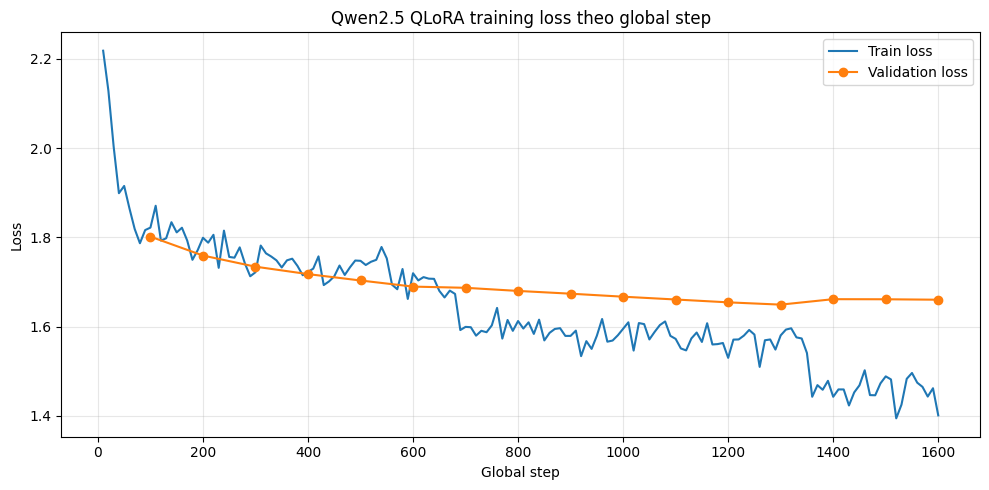

,epoch,train_loss,validation_loss
0,0,1.825090,1.734456
1,1,1.656978,1.667200
2,2,1.524255,1.660428


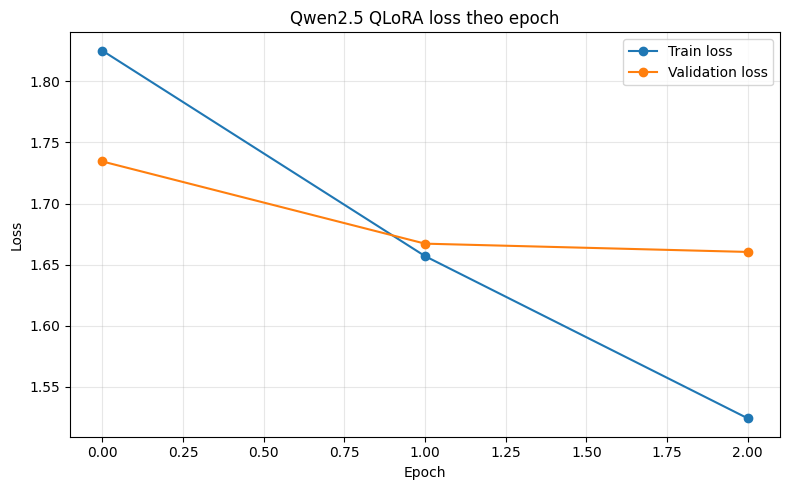

Đã lưu lịch sử loss tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_loss_history.csv
Đã lưu biểu đồ loss theo global step tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_loss_curve.png
Đã lưu lịch sử loss theo epoch tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_epoch_loss_history.csv
Đã lưu biểu đồ loss theo epoch tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_epoch_loss_curve.png


In [12]:
log_history = pd.DataFrame(trainer.state.log_history)
log_history.to_csv(LOSS_HISTORY_CSV, index=False)

# Tách log train và log validation.
train_logs = log_history.dropna(subset=["loss"]).copy() if "loss" in log_history.columns else pd.DataFrame()
eval_logs = log_history.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_history.columns else pd.DataFrame()

# Chuẩn hóa cột step/epoch để tránh lỗi nếu một số bản transformers không ghi đủ cột.
for df in [train_logs, eval_logs]:
    if not df.empty:
        if "step" not in df.columns:
            df["step"] = np.arange(len(df))
        if "epoch" not in df.columns:
            df["epoch"] = np.nan

# ============================================================
# 1. Biểu đồ loss theo global step
# ============================================================
plt.figure(figsize=(10, 5))

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], label="Train loss")

if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="Validation loss")

plt.xlabel("Global step")
plt.ylabel("Loss")
plt.title("Qwen2.5 QLoRA training loss theo global step")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_CURVE_PNG, dpi=150)
plt.show()

# ============================================================
# 2. Bảng và biểu đồ loss theo epoch
# ============================================================
epoch_rows = []

if not train_logs.empty and "epoch" in train_logs.columns:
    tmp_train = train_logs.dropna(subset=["epoch"]).copy()
    if not tmp_train.empty:
        tmp_train["epoch_id"] = tmp_train["epoch"].astype(float).round().astype(int)
        train_epoch_df = (
            tmp_train.groupby("epoch_id", as_index=False)["loss"]
            .mean()
            .rename(columns={"loss": "train_loss"})
        )
    else:
        train_epoch_df = pd.DataFrame(columns=["epoch_id", "train_loss"])
else:
    train_epoch_df = pd.DataFrame(columns=["epoch_id", "train_loss"])

if not eval_logs.empty and "epoch" in eval_logs.columns:
    tmp_eval = eval_logs.dropna(subset=["epoch"]).copy()
    if not tmp_eval.empty:
        tmp_eval["epoch_id"] = tmp_eval["epoch"].astype(float).round().astype(int)
        eval_epoch_df = (
            tmp_eval.groupby("epoch_id", as_index=False)["eval_loss"]
            .last()
            .rename(columns={"eval_loss": "validation_loss"})
        )
    else:
        eval_epoch_df = pd.DataFrame(columns=["epoch_id", "validation_loss"])
else:
    eval_epoch_df = pd.DataFrame(columns=["epoch_id", "validation_loss"])

epoch_loss_df = pd.merge(train_epoch_df, eval_epoch_df, on="epoch_id", how="outer").sort_values("epoch_id")
epoch_loss_df = epoch_loss_df.rename(columns={"epoch_id": "epoch"})
epoch_loss_df.to_csv(EPOCH_LOSS_HISTORY_CSV, index=False)

if not epoch_loss_df.empty:
    display(epoch_loss_df)

    plt.figure(figsize=(8, 5))
    if "train_loss" in epoch_loss_df.columns and epoch_loss_df["train_loss"].notna().any():
        plt.plot(epoch_loss_df["epoch"], epoch_loss_df["train_loss"], marker="o", label="Train loss")
    if "validation_loss" in epoch_loss_df.columns and epoch_loss_df["validation_loss"].notna().any():
        plt.plot(epoch_loss_df["epoch"], epoch_loss_df["validation_loss"], marker="o", label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Qwen2.5 QLoRA loss theo epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EPOCH_LOSS_CURVE_PNG, dpi=150)
    plt.show()
else:
    print("Không đủ dữ liệu để vẽ loss theo epoch.")

print(f"Đã lưu lịch sử loss tại: {LOSS_HISTORY_CSV}")
print(f"Đã lưu biểu đồ loss theo global step tại: {LOSS_CURVE_PNG}")
print(f"Đã lưu lịch sử loss theo epoch tại: {EPOCH_LOSS_HISTORY_CSV}")
print(f"Đã lưu biểu đồ loss theo epoch tại: {EPOCH_LOSS_CURVE_PNG}")


## Cell 11 — Hàm load lại model đã fine-tune để inference

Cell này định nghĩa hàm load lại model gốc và cắm LoRA adapter đã train.  
Nên dùng hàm này sau khi restart runtime hoặc khi vài ngày sau bạn mới có test set.


In [13]:
def load_trained_qwen_model(adapter_dir=ADAPTER_DIR):
    """Load tokenizer, base model 4-bit và LoRA adapter đã fine-tune."""

    adapter_dir = Path(adapter_dir)
    if not (adapter_dir / "adapter_config.json").exists():
        raise FileNotFoundError(
            f"Không tìm thấy adapter_config.json trong {adapter_dir}. "
            "Bạn cần train xong hoặc copy adapter từ Drive về trước khi inference."
        )

    tok = AutoTokenizer.from_pretrained(str(adapter_dir), trust_remote_code=True)
    tok.padding_side = "left"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_cfg,
        device_map="auto",
        trust_remote_code=True,
    )

    loaded_model = PeftModel.from_pretrained(base_model, str(adapter_dir))
    loaded_model.eval()

    return tok, loaded_model


# Dọn bớt bộ nhớ trước khi load lại model inference.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

tokenizer, model = load_trained_qwen_model()
print("Đã load model fine-tuned để inference.")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Đã load model fine-tuned để inference.


## Cell 12 — Hàm tạo prompt và sinh tóm tắt

Cell này định nghĩa prompt inference và hàm sinh summary theo batch. Các tham số sinh như `MAX_NEW_TOKENS`, `NUM_BEAMS`, `NO_REPEAT_NGRAM_SIZE`, `REPETITION_PENALTY` đã được khai báo ở Cell 2 để dễ chỉnh khi cần so sánh nhiều cấu hình.

In [14]:
def build_inference_prompt(article):
    """Tạo prompt ChatML cho bài toán tóm tắt."""
    article = clean_text(article)
    messages = [
        {
            "role": "system",
            "content": "Bạn là hệ thống tóm tắt văn bản tiếng Việt. Hãy tóm tắt ngắn gọn, đúng ý chính, không bịa thông tin.",
        },
        {
            "role": "user",
            "content": f"Tóm tắt văn bản sau bằng tiếng Việt:\n\n{article}",
        },
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def postprocess_summary(text):
    """Làm sạch output sinh ra từ model."""
    text = clean_text(text)
    text = text.replace("<|im_end|>", "").replace("<|im_start|>", "")
    return text.strip()


def generate_summaries(articles, batch_size=GENERATION_BATCH_SIZE):
    """Sinh summary cho danh sách article."""
    predictions = []

    model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    for start in tqdm(range(0, len(articles), batch_size), desc="Generating summaries"):
        batch_articles = articles[start:start + batch_size]
        prompts = [build_inference_prompt(article) for article in batch_articles]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_PROMPT_LENGTH,
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}
        prompt_token_length = inputs["input_ids"].shape[1]

        generate_kwargs = dict(
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=NUM_BEAMS,
            do_sample=DO_SAMPLE,
            repetition_penalty=REPETITION_PENALTY,
            no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        if DO_SAMPLE:
            generate_kwargs["temperature"] = TEMPERATURE
            generate_kwargs["top_p"] = TOP_P

        with torch.no_grad():
            outputs = model.generate(**inputs, **generate_kwargs)

        generated_tokens = outputs[:, prompt_token_length:]
        decoded = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        predictions.extend([postprocess_summary(item) for item in decoded])

        del inputs, outputs, generated_tokens
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return predictions


## Cell 13 — Chạy thử inference trên một mẫu validation

Cell này lấy một mẫu trong validation set để kiểm tra nhanh model có sinh được tóm tắt đúng định dạng hay không.  
Nên chạy cell này trước khi generate toàn bộ validation/test để phát hiện lỗi sớm.


In [15]:
sample = dataset["validation"][0]
sample_prediction = generate_summaries([sample["article"]], batch_size=1)[0]

print("===== ARTICLE =====")
print(clean_text(sample["article"])[:1200])

print("\n===== REFERENCE SUMMARY =====")
print(clean_text(sample["summary"]))

print("\n===== MODEL PREDICTION =====")
print(sample_prediction)


Generating summaries:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


===== ARTICLE =====
Giải thưởng công bố gần đây bởi World Travel Awards. Đây là năm thứ hai liên tiếp InterContinental Phu Quoc Long Beach Resort được vinh danh ở hạng mục gia đình trên toàn châu Á. Khu nghỉ dưỡng tọa lạc bên biển Phú Quốc, nổi bật với thiết kế lấy cảm hứng từ đại dương. Khuôn viên rộng rãi với nhiều mảng xanh thiên nhiên đậm chất nhiệt đới. Không gian sảnh lễ tân, phòng nghỉ, villa, nhà hàng... đều được chú trọng để tạo sự hài hòa với biển và cây cối. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, biệt thự cao cấp hướng biển. Mỗi không gian được thiết kế dựa trên tinh thần gắn kết các thành viên trong gia đình. Bên cạnh tiện nghi sang trọng, InterContinental Phu Quoc còn hút khách gia đình nhờ loạt trải nghiệm giải trí, thư giãn đa dạng, phù hợp với mọi độ tuổi. Với trẻ nhỏ, khu Planet Trekker là nơi các bé có thể thoải mái vui chơi, học hỏi từ các đầu sách thiếu nhi, những buổi workshop thủ công... Phụ huyn

## Cell 14 — Sinh prediction trên validation set

Cell này sinh tóm tắt cho toàn bộ validation set và lưu ra CSV.  
File CSV này dùng để đọc prediction thủ công, tính metric và đưa ví dụ vào báo cáo.


In [16]:
val_df = pd.DataFrame(dataset["validation"])

if DEBUG_MODE:
    val_df = val_df.head(DEBUG_VAL_SIZE).copy()

val_articles = val_df["article"].astype(str).tolist()

val_references = val_df["summary"].astype(str).tolist()

val_predictions = generate_summaries(val_articles)

val_result_df = pd.DataFrame({
    "article": val_articles,
    "reference": val_references,
    "prediction": val_predictions,
})

val_result_df.to_csv(VAL_PRED_CSV, index=False, encoding="utf-8-sig")
print(f"Đã lưu prediction validation tại: {VAL_PRED_CSV}")
val_result_df.head()


Generating summaries:   0%|          | 0/169 [00:00<?, ?it/s]

Đã lưu prediction validation tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_validation_predictions.csv


,article,reference,prediction
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...,InterContinentalPhu Quôc Long Beach Resortđược...
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...,Việt Nam đứng thứ 14 trong bảng xếp 25 quốc gi...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ...",Ngày Hội Văn hóa Thể thạo và Du Lịch các dân t...
3,Giải thưởng do Tạp chí du lịch Condé Nast Trav...,"Phú Quốc, đảo ngọc của Việt Nam, đã được vinh ...",Phú Quốc đã được vân danh tại Giải thưởng du l...
4,KKday Vietnam vừa công bố hợp tác chiến lược S...,KKday Vietnam vừa công bố hợp tác chiến lược v...,KKday Việt Nam đã hợp tác chặt chẽ với Swiss T...


## Cell 15 — Hàm tính ROUGE, BERTScore, BLEU và các metric độ dài

Cell này định nghĩa hàm metric dùng chung cho validation và test.  
Các độ đo gồm ROUGE, BERTScore, BLEU, Too Short Rate, Empty Prediction Rate và thống kê độ dài summary.


In [17]:
def token_count(text):
    """Đếm token đơn giản theo khoảng trắng để tính thống kê độ dài."""
    return len(clean_text(text).split())


def safe_mean(values):
    return float(np.mean(values)) if len(values) > 0 else 0.0


def compute_summarization_metrics(predictions, references, output_json_path=None):
    """Tính các metric chính cho bài toán tóm tắt."""

    predictions = [clean_text(item) for item in predictions]
    references = [clean_text(item) for item in references]

    rouge_metric = evaluate.load("rouge")
    sacrebleu_metric = evaluate.load("sacrebleu")

    rouge_results = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False,
    )

    bleu_results = sacrebleu_metric.compute(
        predictions=predictions,
        references=[[ref] for ref in references],
    )

    pred_lengths = [token_count(item) for item in predictions]
    ref_lengths = [token_count(item) for item in references]

    length_ratios = [
        pred_len / ref_len if ref_len > 0 else 0.0
        for pred_len, ref_len in zip(pred_lengths, ref_lengths)
    ]

    empty_prediction_rate = safe_mean([1.0 if pred_len == 0 else 0.0 for pred_len in pred_lengths])

    too_short_flags = []
    for pred_len, ref_len, ratio in zip(pred_lengths, ref_lengths, length_ratios):
        is_too_short = (pred_len < TOO_SHORT_MIN_TOKENS) or (ref_len > 0 and ratio < TOO_SHORT_RATIO)
        too_short_flags.append(1.0 if is_too_short else 0.0)

    metrics = {
        "num_samples": len(predictions),
        "rouge1": float(rouge_results["rouge1"]),
        "rouge2": float(rouge_results["rouge2"]),
        "rougeL": float(rouge_results["rougeL"]),
        "rougeLsum": float(rouge_results["rougeLsum"]),
        "bleu": float(bleu_results["score"]),
        "empty_prediction_rate": float(empty_prediction_rate),
        "too_short_rate": float(safe_mean(too_short_flags)),
        "avg_prediction_tokens": float(safe_mean(pred_lengths)),
        "avg_reference_tokens": float(safe_mean(ref_lengths)),
        "avg_length_ratio": float(safe_mean(length_ratios)),
    }

    if RUN_BERTSCORE:
        print("Đang tính BERTScore. Bước này có thể mất vài phút...")
        bertscore_metric = evaluate.load("bertscore")
        bertscore_results = bertscore_metric.compute(
            predictions=predictions,
            references=references,
            lang=BERTSCORE_LANG,
            batch_size=METRIC_BATCH_SIZE,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )

        metrics.update({
            "bertscore_precision": float(np.mean(bertscore_results["precision"])),
            "bertscore_recall": float(np.mean(bertscore_results["recall"])),
            "bertscore_f1": float(np.mean(bertscore_results["f1"])),
        })

    if output_json_path is not None:
        output_json_path = Path(output_json_path)
        output_json_path.parent.mkdir(parents=True, exist_ok=True)
        with open(output_json_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)

    return metrics


def show_metrics(metrics):
    display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))


## Cell 16 — Tính metric trên validation set

Cell này dùng prediction đã sinh ở validation để tính toàn bộ metric.  
Kết quả được lưu thành JSON để bạn có thể so sánh với các model khác như ViT5, Transformer scratch hoặc Qwen cấu hình khác.


In [18]:
val_metrics = compute_summarization_metrics(
    predictions=val_result_df["prediction"].tolist(),
    references=val_result_df["reference"].tolist(),
    output_json_path=VAL_METRICS_JSON,
)

print("===== VALIDATION METRICS =====")
show_metrics(val_metrics)
print(f"Đã lưu metric validation tại: {VAL_METRICS_JSON}")


Đang tính BERTScore. Bước này có thể mất vài phút...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


===== VALIDATION METRICS =====


,value
num_samples,1349.000000
rouge1,0.674526
rouge2,0.301650
rougeL,0.371597
rougeLsum,0.371510
bleu,5.605230
empty_prediction_rate,0.000000
too_short_rate,0.001483
avg_prediction_tokens,90.431431
avg_reference_tokens,102.068199


Đã lưu metric validation tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_validation_metrics.json


## Cell 17 — Module test cho `test.parquet`

Cell này đã chuẩn bị sẵn để vài hôm nữa khi có test set bạn không cần code lại.  
Chỉ cần đặt file test vào `/content/NLP/data/test.parquet` rồi chạy cell này. Nếu chưa có test file, cell sẽ tự bỏ qua và in hướng dẫn.


In [20]:
TEST_PATH = first_existing_path(TEST_CANDIDATES, required=False, name="test file")

if TEST_PATH is None:
    print("Chưa tìm thấy test file.")
    print("Khi có test set, hãy đặt file tại một trong các đường dẫn sau:")
    for path in TEST_CANDIDATES:
        print(f"- {path}")
else:
    print(f"Đang tải test set từ: {TEST_PATH}")

    test_dataset = load_dataset(
        "parquet",
        data_files={"test": str(TEST_PATH)},
    )["test"]

    missing = required_columns - set(test_dataset.column_names)
    if missing:
        raise ValueError(
            f"Test set thiếu các cột bắt buộc: {missing}. "
            f"Các cột hiện có: {test_dataset.column_names}"
        )

    if DEBUG_MODE:
        test_n = min(DEBUG_TEST_SIZE, len(test_dataset))
        test_dataset = test_dataset.select(range(test_n))
        print(f"DEBUG_MODE=True → test={test_n}")

    test_df = pd.DataFrame(test_dataset)
    test_articles = test_df["article"].astype(str).tolist()
    test_references = test_df["summary"].astype(str).tolist()

    test_predictions = generate_summaries(test_articles)

    test_result_df = pd.DataFrame({
        "article": test_articles,
        "reference": test_references,
        "prediction": test_predictions,
    })

    test_result_df.to_csv(TEST_PRED_CSV, index=False, encoding="utf-8-sig")
    print(f"Đã lưu prediction test tại: {TEST_PRED_CSV}")

    test_metrics = compute_summarization_metrics(
        predictions=test_result_df["prediction"].tolist(),
        references=test_result_df["reference"].tolist(),
        output_json_path=TEST_METRICS_JSON,
    )

    print("===== TEST METRICS =====")
    show_metrics(test_metrics)
    print(f"Đã lưu metric test tại: {TEST_METRICS_JSON}")


Đang tải test set từ: /content/NLP/data/test.parquet


Generating summaries:   0%|          | 0/168 [00:00<?, ?it/s]

Đã lưu prediction test tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_test_predictions.csv
Đang tính BERTScore. Bước này có thể mất vài phút...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


===== TEST METRICS =====


,value
num_samples,1344.000000
rouge1,0.677866
rouge2,0.302595
rougeL,0.371121
rougeLsum,0.370986
bleu,5.723671
empty_prediction_rate,0.000000
too_short_rate,0.000000
avg_prediction_tokens,91.828869
avg_reference_tokens,103.313988


Đã lưu metric test tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb/qwen_a100_40gb_test_metrics.json


## Cell 18 — Nén output để tải về hoặc lưu Google Drive

Cell này nén toàn bộ output của lần chạy, gồm LoRA adapter, tokenizer, prediction, metric, lịch sử loss và biểu đồ loss. Sau khi chạy xong, bạn nên tải file `.zip` về máy hoặc backup sang Google Drive để tránh mất kết quả khi Colab tắt runtime.

In [21]:
# Tạo file zip chứa adapter, prediction, metric và biểu đồ loss.
if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

shutil.make_archive(
    base_name=str(OUTPUT_ZIP).replace(".zip", ""),
    format="zip",
    root_dir=str(OUTPUT_DIR),
)

print(f"Đã nén output tại: {OUTPUT_ZIP}")

# Nếu muốn copy sang Google Drive, bỏ comment các dòng dưới:
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_BACKUP_DIR = Path('/content/drive/MyDrive/NLP/qwen_backup')
# DRIVE_BACKUP_DIR.mkdir(parents=True, exist_ok=True)
# shutil.copy2(OUTPUT_ZIP, DRIVE_BACKUP_DIR / OUTPUT_ZIP.name)
# print(f"Đã backup zip sang Drive: {DRIVE_BACKUP_DIR / OUTPUT_ZIP.name}")


Đã nén output tại: /content/NLP/output/qwen2_5_1_5b_qlora_a100_40gb_outputs.zip
